# AI/ML Engineering Challenge: Predictive Product Categorizer 🤖🛒

In the world of e-commerce, accurate product categorization is essential for a seamless user experience. Manually assigning categories to thousands of new products is time-consuming and prone to human error.

In [3]:
# importing libraries
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
!pip install -U spacy

In [5]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 91.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Data Loading

This is the classification based E-commerce text dataset for 4 categories - "Electronics", "Household", "Books" and "Clothing & Accessories", which almost cover 80% of any E-commerce website.

The Data is gotten from [Kaggle](https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification?utm_source=chatgpt.com)

In [34]:
df = pd.read_csv("/content/ecommerceDataset.csv", engine="python", on_bad_lines="skip", header=None)

In [35]:
df.sample()

,0,1
4868,Household,AJANTA ROYAL Individual Synthetic Polymer Wood...


### Data Cleaning

In [36]:
# see number of valid entries
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50425 entries, 0 to 50424
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       50425 non-null  object
 1   1       50424 non-null  object
dtypes: object(2)
memory usage: 788.0+ KB


In [37]:
# rename column names
df.columns = ['category', 'description']

In [38]:
# check for unique categories
df.category.value_counts()

,count
category,
Household,19313
Books,11820
Electronics,10621
Clothing & Accessories,8671


### More Preprocessing

In [41]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # remove special chars
    tokens = word_tokenize(text)          # tokenize
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

In [57]:
# view number of null entries per colum
df.isnull().sum()

,0
category,0
description,1
clean_description,0


In [43]:
df['clean_description'] = df['description'].apply(clean_text)

In [44]:
print(df[['description', 'clean_description']])

                                             description  \
0      Paper Plane Design Framed Wall Hanging Motivat...   
1      SAF 'Floral' Framed Painting (Wood, 30 inch x ...   
2      SAF 'UV Textured Modern Art Print Framed' Pain...   
3      SAF Flower Print Framed Painting (Synthetic, 1...   
4      Incredible Gifts India Wooden Happy Birthday U...   
...                                                  ...   
50420  Strontium MicroSD Class 10 8GB Memory Card (Bl...   
50421  CrossBeats Wave Waterproof Bluetooth Wireless ...   
50422  Karbonn Titanium Wind W4 (White) Karbonn Titan...   
50423  Samsung Guru FM Plus (SM-B110E/D, Black) Colou...   
50424                   Micromax Canvas Win W121 (White)   

                                       clean_description  
0      paper plane design framed wall hanging motivat...  
1      saf floral framed painting wood inch x inch sp...  
2      saf uv textured modern art print framed painti...  
3      saf flower print framed painting syn

### Feature Engineering

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [46]:
# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_features=1000,      # limit to top 1000 words by importance (tune as needed)
    ngram_range=(1,2),      # use unigrams and bigrams
    min_df=2                # ignore words that appear in <2 documents
)

# Fit and transform
X = vectorizer.fit_transform(df['clean_description'])

# Convert to DataFrame for inspection
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

print(tfidf_df.head())

    ab   ac  access  accessory  accurate  across    action  activity  adapter  \
0  0.0  0.0     0.0        0.0       0.0     0.0  0.000000       0.0      0.0   
1  0.0  0.0     0.0        0.0       0.0     0.0  0.000000       0.0      0.0   
2  0.0  0.0     0.0        0.0       0.0     0.0  0.100200       0.0      0.0   
3  0.0  0.0     0.0        0.0       0.0     0.0  0.127251       0.0      0.0   
4  0.0  0.0     0.0        0.0       0.0     0.0  0.000000       0.0      0.0   

        add  ...  writing  written      year  yellow  yes  yet  york  \
0  0.075554  ...      0.0      0.0  0.059476     0.0  0.0  0.0   0.0   
1  0.000000  ...      0.0      0.0  0.000000     0.0  0.0  0.0   0.0   
2  0.076262  ...      0.0      0.0  0.000000     0.0  0.0  0.0   0.0   
3  0.096851  ...      0.0      0.0  0.000000     0.0  0.0  0.0   0.0   
4  0.097353  ...      0.0      0.0  0.000000     0.0  0.0  0.0   0.0   

   york time  youll  youre  
0        0.0    0.0    0.0  
1        0.0    0.0   

### Training a Model

In [47]:
y = df["category"]

In [48]:
# ---- Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [49]:
# ---- Baseline model ----
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [50]:
print(y_train.unique())

['Books' 'Household' 'Electronics' 'Clothing & Accessories']


In [53]:
# ---- Evaluate ----
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9430837878036689
                        precision    recall  f1-score   support

                 Books       0.95      0.94      0.95      2364
Clothing & Accessories       0.96      0.96      0.96      1734
           Electronics       0.95      0.91      0.93      2124
             Household       0.93      0.96      0.94      3863

              accuracy                           0.94     10085
             macro avg       0.95      0.94      0.94     10085
          weighted avg       0.94      0.94      0.94     10085



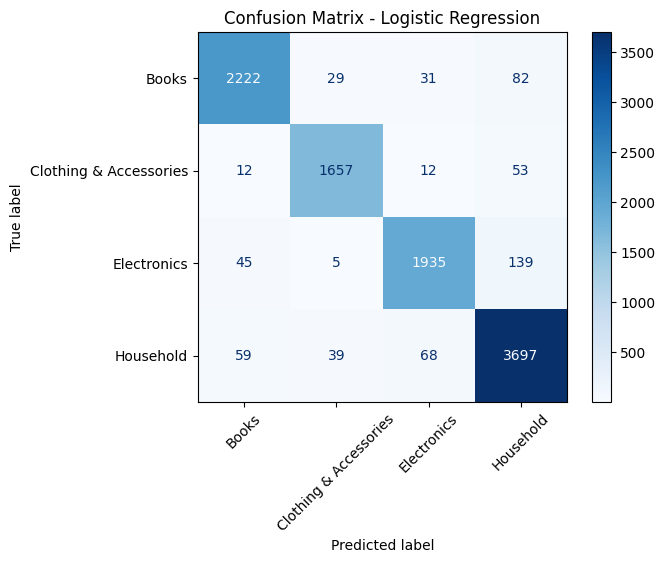

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Display nicely
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


### Save Model and Vectorizer

In [54]:
import joblib

In [55]:
# Save
joblib.dump(clf, "logistic_prodcatger_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [58]:
!pip freeze > requirements.txt

### Copy to GitHub

In [59]:
!git config --global user.email "mtsokanlawon@gmail.com"
!git config --global user.name "mtsokanlawon"

In [66]:
!git clone https://my_token@github.com/mtsokanlawon/product_categorizer_bf.git

Cloning into 'product_categorizer_bf'...


In [67]:
!cp /content/logistic_prodcatger_model.pkl product_categorizer_bf/
!cp /content/tfidf_vectorizer.pkl product_categorizer_bf/
!cp -r /content/ecommerceDataset.csv product_categorizer_bf/
!cp /ProductCategorizer.ipynb product_categorizer_bf/

cp: cannot stat '/ProductCategorizer.ipynb': No such file or directory


In [68]:
%cd product_categorizer_bf/
!git add .
!git commit -m "Added trained model and dataset"
!git push

/content/product_categorizer_bf/product_categorizer_bf
[main (root-commit) 1f7c7f0] Added trained model and dataset
 3 files changed, 50464 insertions(+)
 create mode 100644 ecommerceDataset.csv
 create mode 100644 logistic_prodcatger_model.pkl
 create mode 100644 tfidf_vectorizer.pkl
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 7.81 MiB | 3.23 MiB/s, done.
Total 5 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/mtsokanlawon/product_categorizer_bf.git
 * [new branch]      main -> main
